In [6]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import load_configs, add_config
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

In [7]:
tau = 15
embedding_dim = 20
alpha = 9
beta = 5
simulation_name= generate_input_filename(tau, embedding_dim, alpha, beta)
model_name = "5D,9,5"
scheduler_name = "ReduceLROnPlateau"
print(simulation_name)

delay15dim20_noise9,5


In [8]:
# Percorso del database
model_database_path = "encoderDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

print(model_name)

5D,9,5


In [9]:
# Se vuoi creare una nuova configurazione

layer_dims = [20, 15, 10, 5]
latent_dim = layer_dims[-1]

new_config = {
    "layer_dims" :layer_dims,
    "latent_dim": latent_dim,
    "beta_method": "sigmoid", #constant, sigmoid, linear, linear_decay, exponential_decay
    "beta_value": 0.01, # Valore di beta
    "kl_annealing_epochs":  700, # Epoche di warmup
    "decay_start": 100, # Epoch di inizio del decadimento
    "decay_epoch": 50, # Durata del decadimento
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.01,
    "scheduler": {
        "type": scheduler_name,  # Scheduler alternativo
        "params": {
            "mode": "min",  # Monitorare la perdita minima
            "factor": 0.5,  # Fattore di riduzione
            "patience": 15,  # Epoche prima di ridurre
            "min_lr": 0.0001,  # Limite inferiore
        }
    }
}

epochs = 900

# Aggiungi la nuova configurazione al database
add_config(new_config, model_name, model_database_path)
print(all_configs)

{'1': {'layer_dims': [20, 17, 15, 12, 10, 8, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise3,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}, '2': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20_noise3,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}, '3': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.05, 'kl_annealing_epoc

In [10]:
# Carica una configurazione esistente
selected_model = new_config

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, alpha=alpha, beta=beta, input_path="Simulation data"
)

# Seleziona gli embedding dal SimulationData
input_variable = "y1_embedding"  # Embedding di y1

# Recupera gli embedding da simulation
embedding_y1 = getattr(simulation, input_variable)

# Verifica che gli embedding siano stati generati correttamente
if embedding_y1 is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")

# Crea il dataset
embedded_dataset = EmbeddedDataset(embedding_y1)


print("y1_embedding shape:", simulation.y1_embedding.shape)  # Deve essere (n_samples, embedding_dim)

y1_embedding shape: (9715, 20)


In [11]:

# Suddivisione del dataset
total_size = len(embedding_y1)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"Dimensione del dataset: {total_size}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

# Prepara il DataLoader
batch_size = selected_model["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    x, y = batch  # Decomponi input e output
    x = x.float()
    y = y.float()
    print("Shape of input:", x.shape)
    break



Dimensione del dataset: 9715
Numero di campioni di training: 5829
Numero di campioni di validazione: 3886
Shape of input: torch.Size([32, 20])


Epoch [1/900], Rec Loss: 0.3372, KLD Loss: 6.6677, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.3372, lr = 0.010000
Epoch [2/900], Rec Loss: 0.3103, KLD Loss: 13.8628, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.3103, lr = 0.010000
Epoch [3/900], Rec Loss: 0.2791, KLD Loss: 19.2178, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2791, lr = 0.010000
Epoch [4/900], Rec Loss: 0.2753, KLD Loss: 22.0846, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2753, lr = 0.010000
Epoch [5/900], Rec Loss: 0.2720, KLD Loss: 22.6823, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2720, lr = 0.010000
Epoch [6/900], Rec Loss: 0.2676, KLD Loss: 22.5798, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2676, lr = 0.010000
Epoch [7/900], Rec Loss: 0.2491, KLD Loss: 27.0066, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2491, lr = 0.010000
Epoch [8/900], Rec Loss: 0.2402, KLD Loss: 30.5507, Beta: 0.0000, KLD*B = 0.0000 Training Loss: 0.2402, lr = 0.010000
Epoch [9/900], Rec Loss: 0.2348, KLD Loss: 31.3815, Beta:

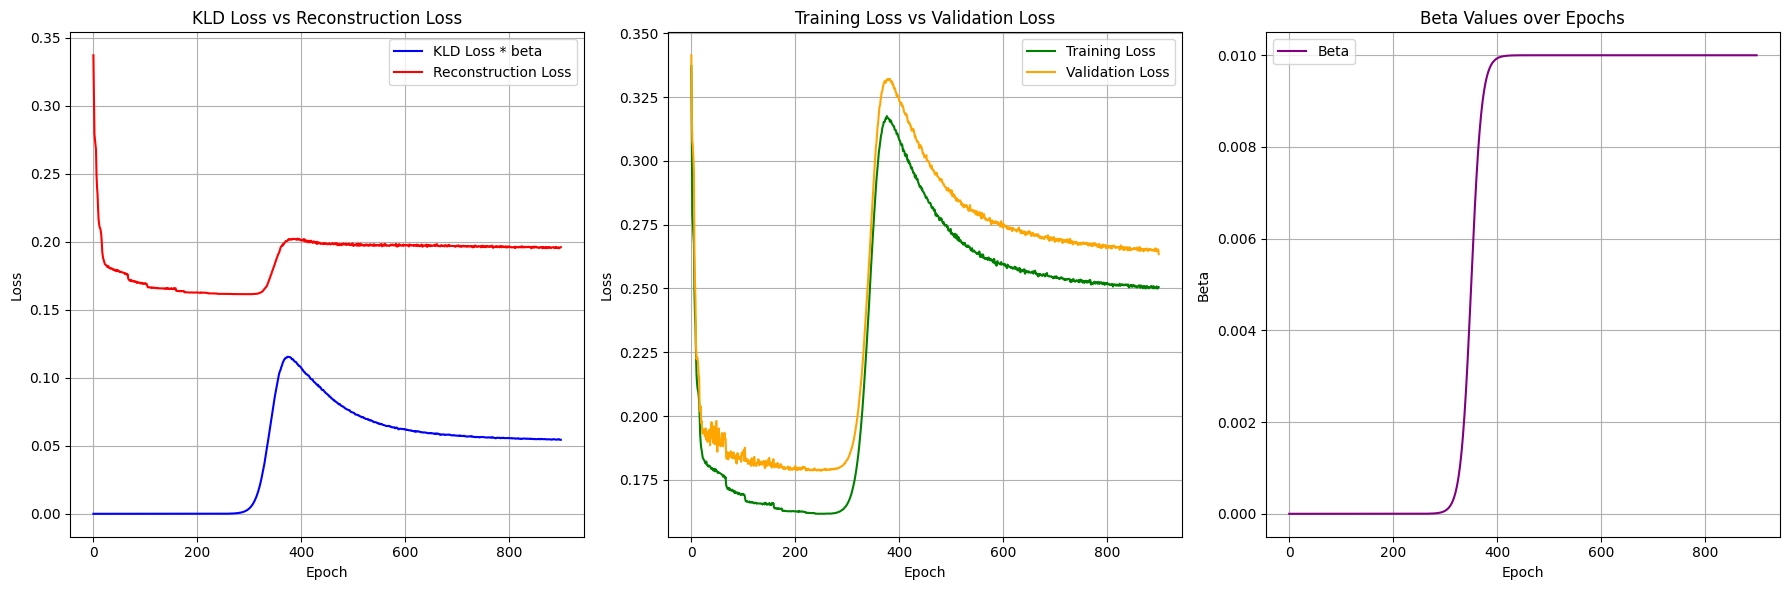

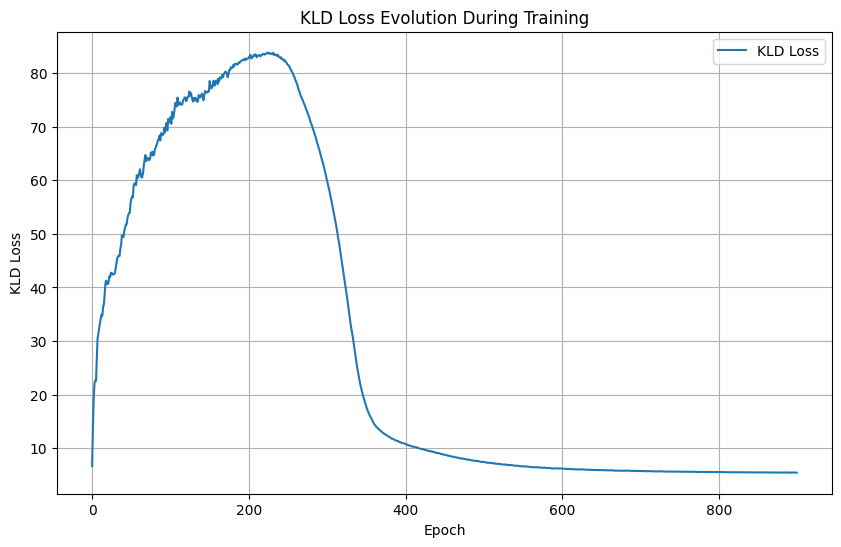

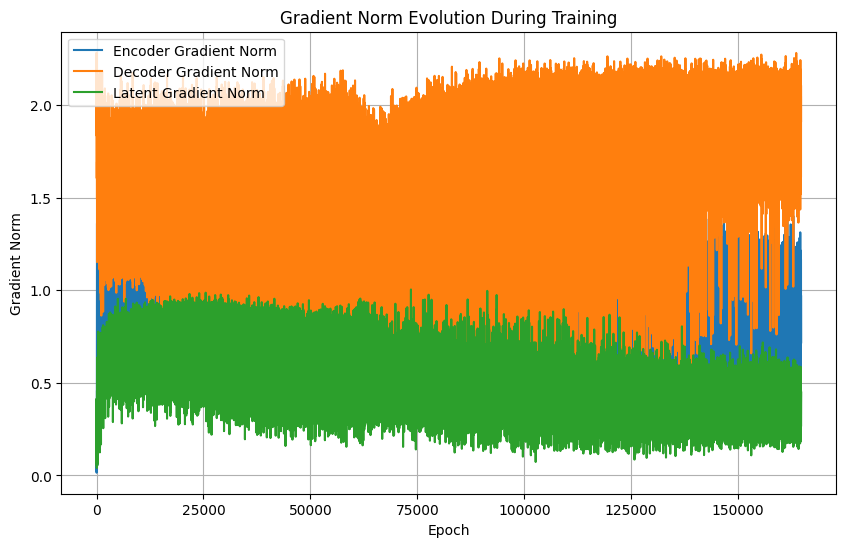

In [12]:
# Creazione del Modello

encoder = Encoder(layer_dims)
decoder = Decoder(layer_dims)

vae_model = VAE(encoder, decoder)

#for name, param in vae_model.named_parameters():
#    print(name, param.shape)

# Configura ottimizzatore e scheduler dai parametri del modello
optimizer = optim.Adam(vae_model.parameters(), lr=selected_model["learning_rate"])
scheduler_config = selected_model.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Esecuzione del training
train_losses, val_losses, recon_losses, kld_losses,effective_kld_losses, beta_values, stopped_epoch, gradient_history, lr_evolution = trainEncoder(
    epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    kl_annealing_epochs=selected_model["kl_annealing_epochs"],
    decay_epoch=selected_model["decay_epoch"],
    decay_start=selected_model["decay_start"],
    beta_method=selected_model["beta_method"],
    beta_value=selected_model["beta_value"],
    early_stopping_params=selected_model["early_stopping"]
)


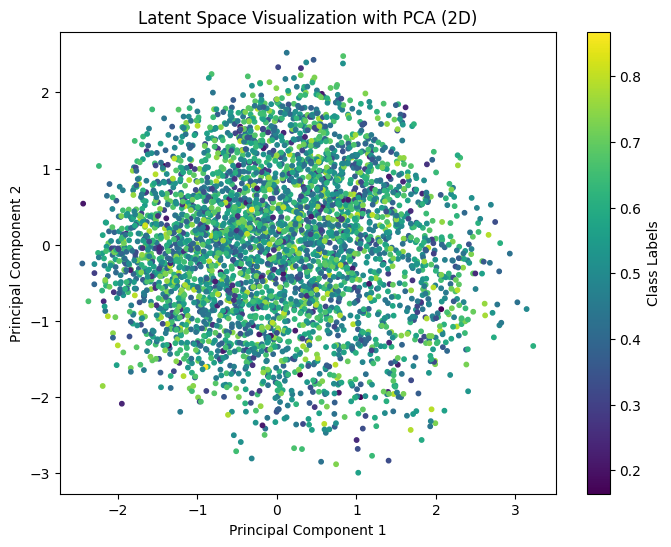

In [13]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

In [14]:
# Carica la configurazione creata nel Databse degli Encoder
all_configs = load_configs(model_database_path)

In [15]:
# Salva il modello
model_name += ".pth"
save_encoder(
    encoder=encoder,
    decoder=decoder,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,  # Aggiungi se hai un dataset di validazione
    epoch=50,
    stopped_epoch=stopped_epoch,
    encoder_layers=layer_dims,
    decoder_layers=layer_dims,
    train_losses=train_losses,
    val_losses=val_losses,
    recon_losses=recon_losses,
    kld_losses=kld_losses,
    effective_kld_losses=effective_kld_losses,
    beta_values=beta_values,
    gradient_history=gradient_history,
    output_folder="Encoder Models",
    model_name=model_name
)

Model saved to Encoder Models/5D,9,5.pth
